# **FGVCAircraft  - CLIP Prompt Tuning**

In [1]:
!pip install ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.1 MB/s eta 0:00:00
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-rdwusied
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-rdwusied
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=d7849ecb7d5cc68aecd4baf8e79192b64dd96c5ccc36641fa2c7bb06973ebf7e
  Stored in directory: /tmp/pip-ephem-wheel-cache-tlwj6cwy/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [2]:
!pip uninstall -y peft torchao
!pip install peft==0.13.2

Found existing installation: peft 0.19.1
Uninstalling peft-0.19.1:
  Successfully uninstalled peft-0.19.1
Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.7/320.7 kB 23.4 MB/s eta 0:00:00


### Imports and  loading FGCVAircraft data

In [3]:
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from peft import LoraConfig, get_peft_model
import torch.nn.functional as F
import clip
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix
import seaborn as sns
from tqdm import tqdm
import time

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


In [4]:
class FGVCAircraftDataset(Dataset):
    def __init__(self, root, split="train", transform=None):
        self.root = root
        self.transform = transform

        with open(os.path.join(root, "variants.txt")) as f:
            self.classes = [line.strip() for line in f.readlines()]

        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}

        split_file = os.path.join(root, f"images_variant_{split}.txt")
        self.samples = []

        with open(split_file) as f:
            for line in f:
                parts = line.strip().split(" ")
                img_name = parts[0]
                label = " ".join(parts[1:])
                img_path = os.path.join(root, "images", f"{img_name}.jpg")

                if label in self.class_to_idx:
                    self.samples.append((img_path, self.class_to_idx[label]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        try:
            image = Image.open(img_path).convert("RGB")
        except:
            image = Image.new("RGB", (224, 224))

        if self.transform:
            image = self.transform(image)

        return image, label

In [5]:
#ensures that the images are in the exact format that CLIP was trained on. If this is skipped, then accuracy will drop significantly.
clip_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.48145466, 0.4578275, 0.40821073),
        std=(0.26862954, 0.26130258, 0.27577711),
    ),
])

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
!cp -r "/content/drive/MyDrive/Colab Notebooks/EEEM068 - Applied Machine Learning/COURSEWORK/data" /content/data
#!cp -r "/content/drive/MyDrive/EEEM068 - Applied Machine Learning/COURSEWORK/data" /content/data
root = "/content/data"

In [8]:
train_dataset = FGVCAircraftDataset(root, "train", clip_transform)
val_dataset   = FGVCAircraftDataset(root, "val", clip_transform)
test_dataset  = FGVCAircraftDataset(root, "test", clip_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64)
test_loader  = DataLoader(test_dataset, batch_size=64)

classnames = train_dataset.classes

print("Classes:", len(classnames))

Classes: 100


### Load CLIP and Models

In [9]:
model, _ = clip.load("ViT-B/16", device=device)
model.eval()

100%|███████████████████████████████████████| 335M/335M [00:04<00:00, 74.0MiB/s]


CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16), bias=False)
    (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): Sequential(
        (0): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=768, out_features=3072, bias=True)
            (gelu): QuickGELU()
            (c_proj): Linear(in_features=3072, out_features=768, bias=True)
          )
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
        (1): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          

##### LoRA

In [10]:
class LoRACLIP(nn.Module):

    def __init__(self, clip_model, num_classes):
        super().__init__()
        self.clip_model = clip_model

        for param in self.clip_model.parameters():
            param.requires_grad = False

        lora_config = LoraConfig(r=32,lora_alpha=64,target_modules=["c_fc", "c_proj"],lora_dropout=0.05, bias="none")
        self.clip_model.visual.transformer = get_peft_model(self.clip_model.visual.transformer,lora_config)
        self.classifier = nn.Sequential(nn.LayerNorm(512), nn.Dropout(0.2),nn.Linear(512, num_classes))

    def forward(self, images):

        image_features = self.clip_model.encode_image(images)
        image_features = image_features.float()
        image_features = image_features / (image_features.norm(dim=-1, keepdim=True) + 1e-6)

        logits = self.classifier(image_features)

        return logits

In [11]:
def compute_validation_loss_lora(model, val_loader):

    model.eval()
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    total_loss = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = criterion(logits, labels)

            if torch.isnan(loss):
                continue

            total_loss += loss.item()

    return total_loss / len(val_loader)

In [12]:
def train_lora(model,train_loader,val_loader,epochs=10,lr=5e-4):

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),lr=lr,weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=epochs)

    scaler = torch.cuda.amp.GradScaler()

    train_losses = []
    val_losses = []

    train_accs = []
    val_accs = []

    best_acc = 0

    for epoch in range(epochs):

        model.train()

        running_loss = 0
        correct = 0
        total = 0

        for images, labels in tqdm(train_loader):

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            try:

                with torch.cuda.amp.autocast():

                    logits = model(images)

                    loss = criterion(logits, labels)

                if not torch.isfinite(loss):
                    continue

                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)

                torch.nn.utils.clip_grad_norm_(model.parameters(),max_norm=1.0)

                scaler.step(optimizer)
                scaler.update()

            except RuntimeError as e:

                print("Runtime Error:", e)
                torch.cuda.empty_cache()
                continue

            running_loss += loss.item()

            preds = logits.argmax(dim=1)

            correct += (preds == labels).sum().item()

            total += labels.size(0)

        scheduler.step()

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        val_loss = compute_validation_loss_lora(model,val_loader)

        model.eval()

        val_correct = 0
        val_total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                logits = model(images)

                preds = logits.argmax(dim=1)

                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_acc = val_correct / val_total

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

        # Save best model
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(),"best_lora_model.pt")

            print("Best LoRA model saved.")

    return (model,train_losses,val_losses,train_accs,val_accs)

### Evaluate

##### Evaluation Function

In [13]:
def evaluate(text_features, dataloader, name="Model"):
    correct1, correct5, total = 0, 0, 0
    y_true, y_pred = [], []

    print(f"\nEvaluating {name}...")
    start_time = time.time()

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc=f"{name} Progress"):
            images = images.to(device)
            labels = labels.to(device)

            image_features = model.encode_image(images)
            image_features /= image_features.norm(dim=-1, keepdim=True)

            text_features = text_features.to(image_features.dtype)
            #logits = image_features @ text_features.T

            logits = image_features @ text_features.T
### use both top1 and top5 accuracies because the airplane classes are very similar
            # Top-1
            preds = logits.argmax(dim=1)
            correct1 += (preds == labels).sum().item()

            # Top-5
            # is the correct answer in the first 5 guesses
            top5 = logits.topk(5, dim=1).indices
            correct5 += sum([labels[i] in top5[i] for i in range(len(labels))])

            total += labels.size(0)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    end_time = time.time()
    print(f"{name} completed in {end_time - start_time:.2f} seconds")

    return correct1/total, correct5/total, y_true, y_pred

In [14]:
def evaluate_prompt_variance(classnames, templates, dataloader, name="Model"):
    top1_scores = []
    top5_scores = []

    print(f"\nEvaluating variance for {name}...")

    for i, t in enumerate(templates):
        print(f"\nTemplate {i+1}/{len(templates)}: {t}")

        # Build text features for this prompt
        text_features = zero_shot_classifier(classnames, t)

        #evaluation function
        top1, top5, _, _ = evaluate(
            text_features,
            dataloader,
            name=f"{name} | Prompt {i+1}"
        )

        top1_scores.append(top1)
        top5_scores.append(top5)

    # Compute statistics
    mean_top1 = np.mean(top1_scores)
    var_top1  = np.var(top1_scores)

    mean_top5 = np.mean(top5_scores)
    var_top5  = np.var(top5_scores)

    print("\n===== VARIANCE RESULTS =====")
    print(f"{name} Mean Top-1: {mean_top1:.4f}")
    print(f"{name} Var  Top-1: {var_top1:.6f}")
    print(f"{name} Mean Top-5: {mean_top5:.4f}")
    print(f"{name} Var  Top-5: {var_top5:.6f}")

    return {
        "top1_scores": top1_scores,
        "top5_scores": top5_scores,
        "mean_top1": mean_top1,
        "var_top1": var_top1,
        "mean_top5": mean_top5,
        "var_top5": var_top5
    }

In [15]:
def evaluate_fusion_static_model(fusion_model, clip_model, dataloader, name="Fusion"):
    fusion_model.eval()

    correct1, correct5, total = 0, 0, 0

    with torch.no_grad():
        text_features_list = fusion_model()

        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            image_features = clip_model.encode_image(images)
            image_features = image_features / image_features.norm(dim=-1, keepdim=True)

            logits_list = []
            for tf in text_features_list:
                tf = tf.to(image_features.dtype)
                logits = image_features @ tf.T
                logits_list.append(logits)

            fused_logits = sum(logits_list) / len(logits_list)

            preds = fused_logits.argmax(dim=1)
            correct1 += (preds == labels).sum().item()

            top5 = fused_logits.topk(5, dim=1).indices
            correct5 += sum([labels[i] in top5[i] for i in range(labels.size(0))])

            total += labels.size(0)

    top1 = correct1 / total
    top5 = correct5 / total

    print(f"{name} Top-1: {top1:.4f}, Top-5: {top5:.4f}")
    return top1, top5

In [16]:
def evaluate_lora(model, dataloader, name="LoRA"):

    correct1, correct5, total = 0, 0, 0
    y_true, y_pred = [], []

    print(f"\nEvaluating {name}...")
    start_time = time.time()

    model.eval()

    with torch.no_grad():

        for images, labels in tqdm(
            dataloader,
            desc=f"{name} Progress"
        ):

            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)

            # Top-1
            preds = logits.argmax(dim=1)

            correct1 += (preds == labels).sum().item()

            # Top-5
            top5 = logits.topk(5, dim=1).indices

            correct5 += sum(
                [labels[i] in top5[i] for i in range(len(labels))]
            )

            total += labels.size(0)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    end_time = time.time()

    print(
        f"{name} completed in "
        f"{end_time - start_time:.2f} seconds"
    )

    return (correct1 / total, correct5 / total, y_true, y_pred)

##### Evaluation Metrics

In [17]:
results = {}

In [18]:
all_losses = {} ### plotting training ad validation losses

In [19]:
#LoRA
num_classes = len(train_dataset.classes)
lora_model = LoRACLIP(model, num_classes).to(device)

In [20]:
#LoRA

### trainable parameters
trainable = 0
total = 0

for name, param in lora_model.named_parameters():

    total += param.numel()

    if param.requires_grad:
        trainable += param.numel()
        print(name)

print(f"\nTrainable: {trainable:,}")
print(f"Total: {total:,}")

clip_model.visual.transformer.base_model.model.resblocks.0.mlp.c_fc.lora_A.default.weight
clip_model.visual.transformer.base_model.model.resblocks.0.mlp.c_fc.lora_B.default.weight
clip_model.visual.transformer.base_model.model.resblocks.0.mlp.c_proj.lora_A.default.weight
clip_model.visual.transformer.base_model.model.resblocks.0.mlp.c_proj.lora_B.default.weight
clip_model.visual.transformer.base_model.model.resblocks.1.mlp.c_fc.lora_A.default.weight
clip_model.visual.transformer.base_model.model.resblocks.1.mlp.c_fc.lora_B.default.weight
clip_model.visual.transformer.base_model.model.resblocks.1.mlp.c_proj.lora_A.default.weight
clip_model.visual.transformer.base_model.model.resblocks.1.mlp.c_proj.lora_B.default.weight
clip_model.visual.transformer.base_model.model.resblocks.2.mlp.c_fc.lora_A.default.weight
clip_model.visual.transformer.base_model.model.resblocks.2.mlp.c_fc.lora_B.default.weight
clip_model.visual.transformer.base_model.model.resblocks.2.mlp.c_proj.lora_A.default.weight


In [21]:
#LoRA
lora_model, lora_train_losses, lora_val_losses, lora_train_accs, lora_val_accs = train_lora(lora_model,train_loader,val_loader,epochs=10,lr=5e-4)

/tmp/ipykernel_27774/1709323411.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
  0%|          | 0/53 [00:00<?, ?it/s]/tmp/ipykernel_27774/1709323411.py:35: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 53/53 [01:36<00:00,  1.82s/it]



Epoch 1/10
Train Loss: 3.8540 | Val Loss: 2.9616 | Train Acc: 0.1275 | Val Acc: 0.3021
Best LoRA model saved.


100%|██████████| 53/53 [01:28<00:00,  1.68s/it]



Epoch 2/10
Train Loss: 2.4400 | Val Loss: 2.4507 | Train Acc: 0.4529 | Val Acc: 0.4095
Best LoRA model saved.


100%|██████████| 53/53 [01:24<00:00,  1.60s/it]


...


Epoch 8/10
Train Loss: 0.8376 | Val Loss: 1.8163 | Train Acc: 0.9997 | Val Acc: 0.6763
Best LoRA model saved.


100%|██████████| 53/53 [01:24<00:00,  1.59s/it]



Epoch 9/10
Train Loss: 0.8259 | Val Loss: 1.8203 | Train Acc: 1.0000 | Val Acc: 0.6874
Best LoRA model saved.


100%|██████████| 53/53 [01:26<00:00,  1.62s/it]



Epoch 10/10
Train Loss: 0.8214 | Val Loss: 1.8350 | Train Acc: 1.0000 | Val Acc: 0.6874


In [22]:
results["LoRA"] = evaluate_lora(lora_model,test_loader)
all_losses["LoRA"] = {"train": lora_train_losses, "val": lora_val_losses}


Evaluating LoRA...


LoRA Progress: 100%|██████████| 53/53 [01:12<00:00,  1.37s/it]

LoRA completed in 72.45 seconds


##### Evaluation Plots

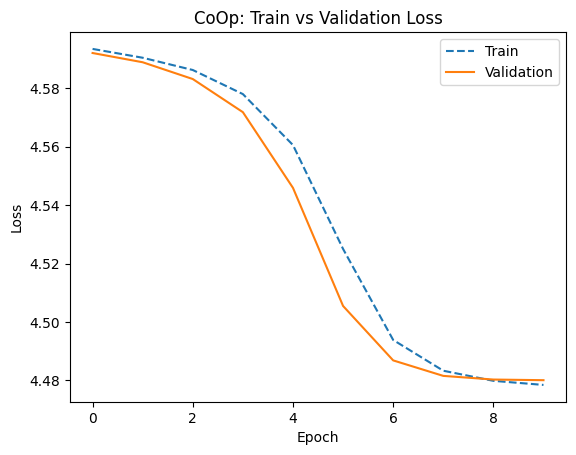

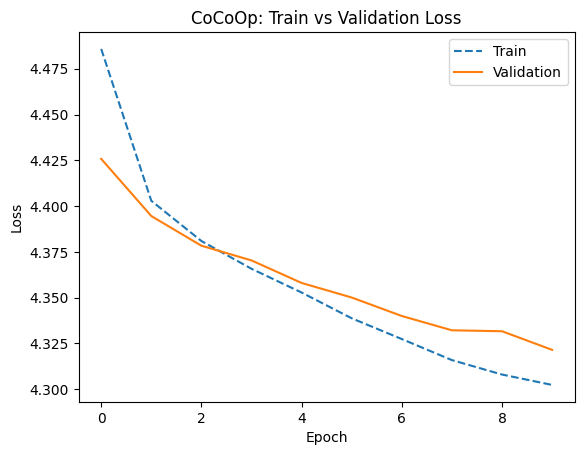

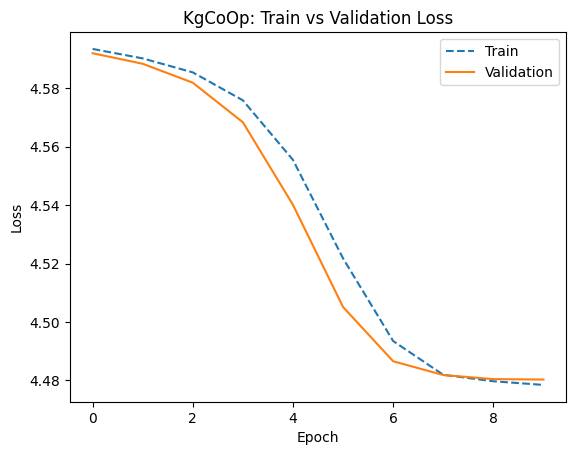

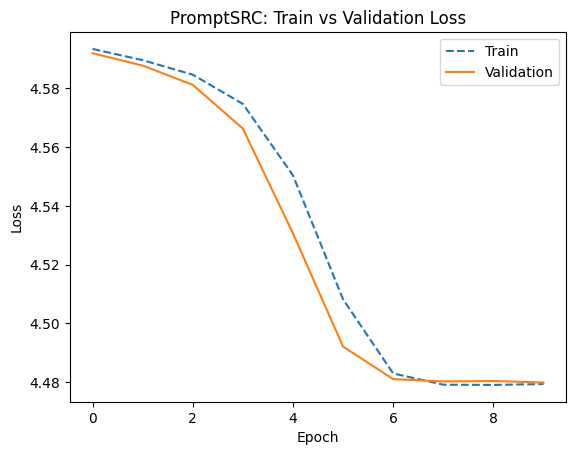

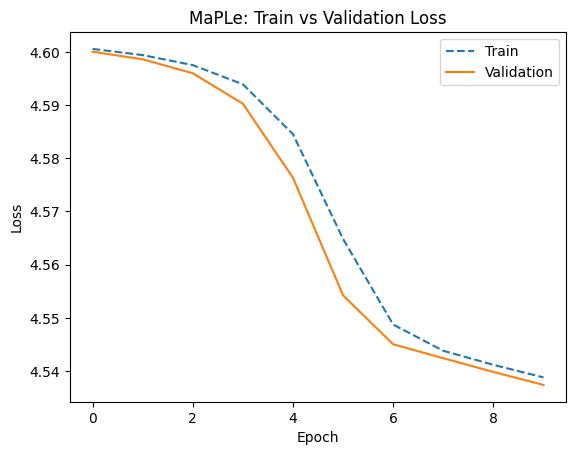

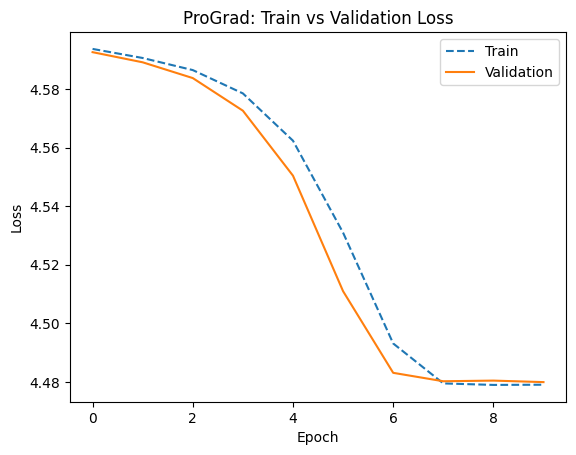

In [ ]:
for name, losses in all_losses.items():
    plt.figure()

    plt.plot(losses["train"], linestyle='--', label="Train")
    plt.plot(losses["val"], linestyle='-', label="Validation")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{name}: Train vs Validation Loss")
    plt.legend()

    plt.show()

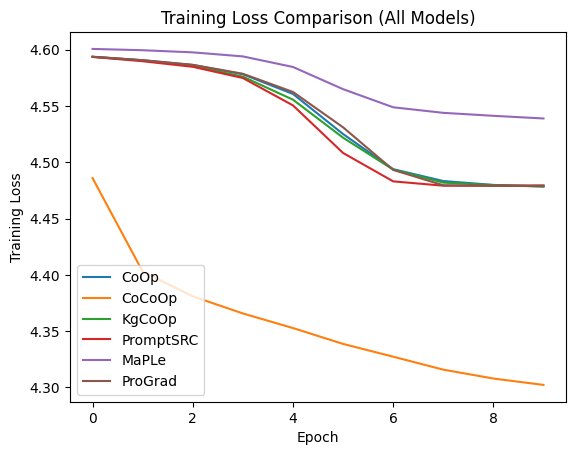

In [ ]:
plt.figure()

for name, losses in all_losses.items():
    plt.plot(losses["train"], label=name)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Comparison (All Models)")
plt.legend()
plt.show()

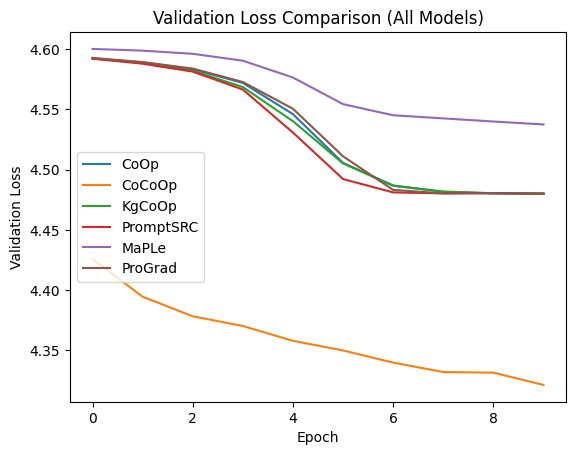

In [ ]:
plt.figure()

for name, losses in all_losses.items():
    plt.plot(losses["val"], label=name)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison (All Models)")
plt.legend()
plt.show()

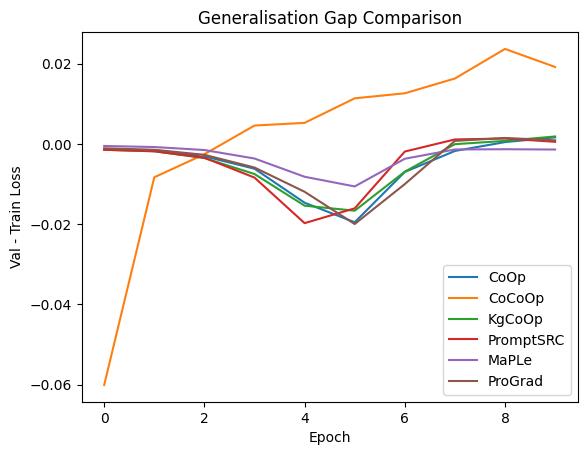

In [ ]:
plt.figure()

for name, losses in all_losses.items():
    gap = [v - t for t, v in zip(losses["train"], losses["val"])]
    plt.plot(gap, label=name)

plt.xlabel("Epoch")
plt.ylabel("Val - Train Loss")
plt.title("Generalisation Gap Comparison")
plt.legend()
plt.show()

In [ ]:
table_data = []

for name in all_losses.keys():
    train_final = all_losses[name]["train"][-1]
    val_final = all_losses[name]["val"][-1]
    acc = results.get(name, None)

    gap = val_final - train_final

    table_data.append([name, train_final, val_final, gap, acc])

df = pd.DataFrame(
    table_data,
    columns=["Model", "Final Train Loss", "Final Val Loss", "Gap", "Accuracy"]
)

df = df.sort_values(by="Accuracy", ascending=False)

print(df)

           Model  Final Train Loss  Final Val Loss       Gap  \
4        ProGrad          4.478774        4.479805  0.001032   
3          MaPLe          4.536090        4.534276 -0.001814   
5  Fusion_Static          4.479039        4.480605  0.001565   
1         KgCoOp          4.480690        4.480837  0.000147   
2      PromptSRC          4.479290        4.480911  0.001621   
0         CoCoOp          4.299528        4.323703  0.024175   

                                            Accuracy  
4  (0.19411941194119411, 0.5079507950795079, [0, ...  
3  (0.18871887188718872, 0.5031503150315032, [0, ...  
5         (0.18031803180318032, 0.47554755475547555)  
1  (0.1773177317731773, 0.46954695469546953, [0, ...  
2  (0.16831683168316833, 0.44854485448544856, [0,...  
0  (0.1038103810381038, 0.3132313231323132, [0, 0...  


In [ ]:
for k, v in results.items():
    print(f"{k}: Top-1={v[0]:.4f}, Top-5={v[1]:.4f}")

LoRA: Top-1=0.7123, Top-5=0.9178


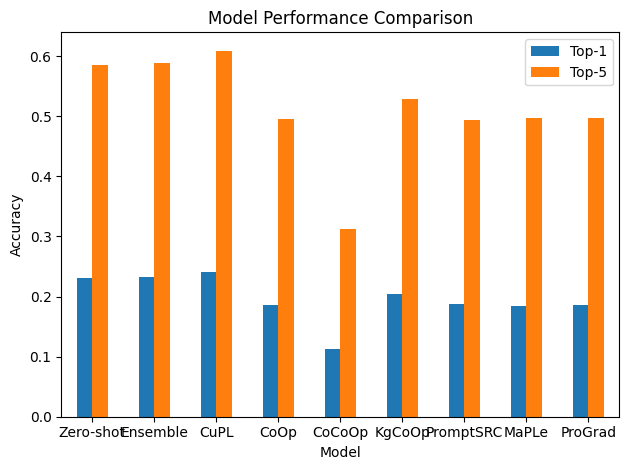

In [ ]:
acc_results = {
    k: (v[0], v[1])  # keep only Top-1 and Top-5 accuracies
    for k, v in results.items()
}
accuracies = pd.DataFrame.from_dict(acc_results,orient='index',columns=["Top-1", "Top-5"])

accuracies.plot(kind='bar')
plt.title("Model Performance Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Zero-shot: Top-1=0.2268, Top-5=0.5734


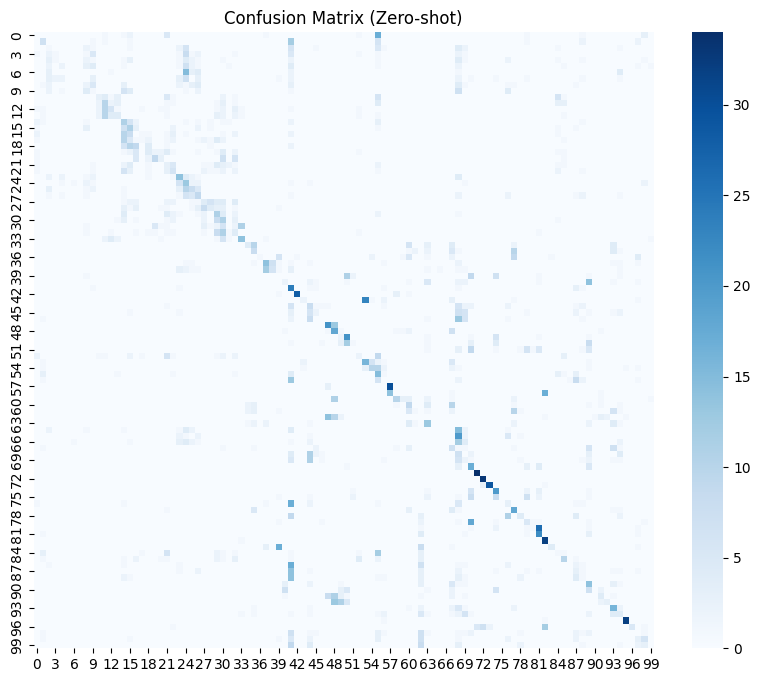

In [ ]:
# CONFUSION MATRIX for one shot
y_true, y_pred = results["Zero-shot"][2], results["Zero-shot"][3]
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix (Zero-shot)")
plt.show()

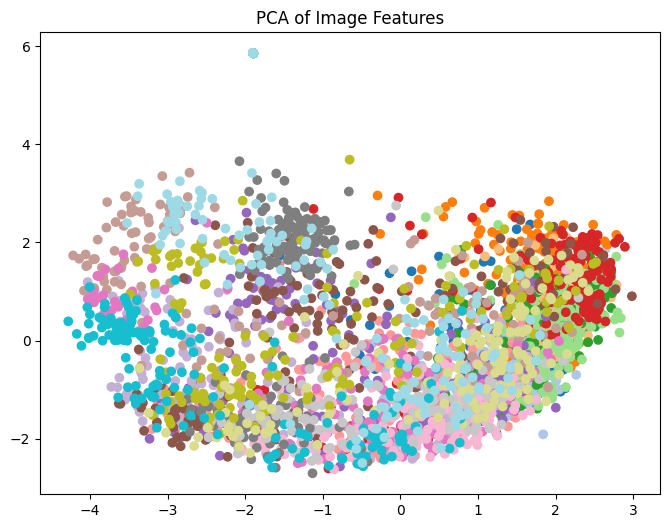

In [ ]:
# Principle Component Analysis - get the most important features
## compare it to the best performing
def get_features(dataloader):
    feats, labels = [], []
    with torch.no_grad():
        for images, y in dataloader:
            images = images.to(device)
            f = model.encode_image(images)
            feats.append(f.cpu().numpy())
            labels.extend(y.numpy())
    return np.vstack(feats), np.array(labels)

features, labels = get_features(test_loader)

pca = PCA(n_components=2)
reduced = pca.fit_transform(features)

plt.figure(figsize=(8,6))
plt.scatter(reduced[:,0], reduced[:,1], c=labels, cmap='tab20')
plt.title("PCA of Image Features")
plt.show()